In [ ]:
pip install ortools #operations research tool

In [ ]:
import numpy as np # md array, numerical computation and matrix operations
import pandas as pd # for data manipulation and importing files
import matplotlib.pyplot as plt #plotting

from sklearn.ensemble import RandomForestRegressor # random forest for regression(ensembled learning(bagging))
from sklearn.model_selection import train_test_split # splitting data into train and test for model training and validation
from sklearn.metrics import mean_absolute_error # for accuracy

from ortools.constraint_solver import pywrapcp, routing_enums_pb2 # pywrapcp - used for python wrapping, creating route model, defining constrants and adding cost functions, routing_enums_pb2 - this is used for search strategies

# **Congestion Modeling**

In [ ]:
distance_matrix = pd.read_csv("distance_matrix_strong.csv").values # .val convertes the file into np arrays
time_matrix = pd.read_csv("time_matrix_strong.csv").values
np.random.seed(42)
node_coords = np.random.rand(len(distance_matrix), 2) * 100

# Strong congestion, this introduces non uniform cost landscape
congestion_nodes = [4, 5, 6] #here i define high traffic zone nodes(eg. urban or industrial areas)

for i in range(len(time_matrix)):
    for j in range(len(time_matrix)):
        if i in congestion_nodes or j in congestion_nodes:
            time_matrix[i][j] *= 2.0   # make congestion severe this changes the time to twice (for eg. time = 20 , if conjestion nodes then the time will be increased to 40)

# **Time Window**

In [ ]:
time_windows = [] # The allowable time interval during which a vehicle can arrive at a location.

for node in range(len(distance_matrix)):
    if node == 0:
        time_windows.append((0, 30000)) # it is the time window of depoting, it can be flexible
    else:
        time_windows.append((0, 25000)) #Customers must be served before time 25000(hard time delivery)

# **Greedy Nearest Neighbor Algorithm Based on Heuristics**

In [ ]:
def greedy_route(matrix): # It computes a route using a greedy nearest neighbor heuristic, shortest unvisited path is visited and end at depot
    n = len(matrix)          #not optimal
    visited = [False] * n
    route = [0]
    visited[0] = True

    for _ in range(n - 1):
        last = route[-1]
        nearest = None
        min_dist = float('inf')

        for i in range(n):
            if not visited[i] and matrix[last][i] < min_dist:   #check if the path is visited or not and Distance from last → i is smaller than current minimum, if not visited and smaller - continue
                min_dist = matrix[last][i]
                nearest = i

        route.append(nearest) # Add nearest node
        visited[nearest] = True

    route.append(0) # back to depot
    return route

# **AI Model Using Random Forest(Regression)**

In [ ]:
np.random.seed(42) #fixes randomness, so everytime we run the model we got same random data, same model and same result
n_samples = 500

data = pd.DataFrame({
    "distance": np.random.randint(5, 60, n_samples), # 5 - 59 km
    "time_of_day": np.random.randint(0, 24, n_samples),   # 0 to 23 hours   #this is synthetic traffic dataset of 500 dataset of each
    "weather": np.random.randint(0, 3, n_samples),        # 0 - clear, 1 - rain, 2 - fog , we assumed this
    "road_type": np.random.randint(0, 2, n_samples),     # 0 - highway, 1 - normal city road
})

data["delay"] = (                                            #delay formula
    0.6 * data["distance"] +
    5 * data["time_of_day"].between(8,10) +
    5 * data["time_of_day"].between(17,19) +
    6 * (data["weather"] == 1) +
    np.random.normal(0, 3, n_samples)                # this is gaussian noise, real worls uncertanity  without this the model jsut memorize thsi formula and hence overfits
)

X = data[["distance", "time_of_day", "weather", "road_type"]]      #independent variables
y = data["delay"]                     #dependent on x

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)    # it is 80 - 20 split to prevent overfitting

model = RandomForestRegressor()        # we uses random forest(regression) because it is ensemble learning, reduces variance, can handle non linear relationships
model.fit(X_train, y_train)            # Random Forest handles non linear relationships and interactions between variables like time of day and weather effectively, and it is robust to noise

print("Model MAE:", mean_absolute_error(y_test, model.predict(X_test)))   #model evaluation with mean absolute error

def predict_delay(distance):
    sample = pd.DataFrame({                   # WORST CASE TRAFFIC SCENARIO
        "distance": [distance],
        "time_of_day": [9],
        "weather": [1],
        "road_type": [0]
    })
    return model.predict(sample)[0]

Model MAE: 3.2670192517134398


# **Spoilage and Emission Model**

In [ ]:
def calculate_spoilage(distance, travel_time): #This models product degradation due to temperature exposure
    delay = predict_delay(distance)
    total_time = travel_time + delay
    refrigeration_efficiency = 0.5   #only 50% of temperature increase is controlled(0.5)
    temp_rise = total_time * (1 - refrigeration_efficiency)

    if temp_rise <= 4: #If temperature increase is not more than 4°C then no changes
        return 0
    return (temp_rise - 4) * 80  # strong sensitivity, strong penalty


def calculate_emission(distance, delay):
    base = 0.3 * distance                    # fuel consumption proportional to distance
    traffic_effect = 0.1 * delay       # so emission increases with congestion(traffic), congestion increases carbon footprints
    return base + traffic_effect

# **Vehicle Routing Problem with Time Windows Solver, Multi-objective optimization using OR-Tools**

In [ ]:
def solve_vrp(distance_matrix, time_matrix, time_windows):

    n = len(distance_matrix)
    manager = pywrapcp.RoutingIndexManager(n, 1, 0) #routing index manager handles mapping between Internal solver indices and Actual node numbers
    routing = pywrapcp.RoutingModel(manager) # here n - number of nodes, 1 - no. of vehicles and 0 - depot node
                                                      # single vehicle routing problem
    def cost_callback(from_index, to_index): #cost of traveling from one node to another, OR-Tools calls this for each possible edge
      from_node = manager.IndexToNode(from_index) #convert index into node
      to_node = manager.IndexToNode(to_index)

      distance = distance_matrix[from_node][to_node]   # extract Edge Data, we use real data here
      travel_time = time_matrix[from_node][to_node]

      delay = predict_delay(distance)  # AI Integration
      spoilage = calculate_spoilage(distance, travel_time)
      emission = calculate_emission(distance, delay)

    # here we do NORMALIZATION Because each metrics are on different scales
      norm_distance = distance / 100
      norm_time = travel_time / 100
      norm_spoilage = spoilage / 10000
      norm_emission = emission / 10

    # Balanced multi-objective, Weights represent importance, our most important factor is SPOILAGE, here we converst multi objectives into simple cost
      return int(10000*(
          2.0 * norm_distance +
          3.0 * norm_time +
          5.0 * norm_spoilage +
          2.0 * norm_emission
       ))
    transit_callback_index = routing.RegisterTransitCallback(cost_callback) # this tells the or tools to Use this function to compute arc costs
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    def time_callback(from_index, to_index):       # this defines pure travel time between nodes, constraint tracking
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return int(time_matrix[from_node][to_node])

    time_callback_index = routing.RegisterTransitCallback(time_callback)

    routing.AddDimension(              #adding time dimensions
        time_callback_index,
        10000,
        40000,           #max time
        False,
        "Time"
    )

    time_dimension = routing.GetDimensionOrDie("Time")

    for node in range(n):
        index = manager.NodeToIndex(node)
        start, end = time_windows[node]
        time_dimension.CumulVar(index).SetRange(start, end)      # arrival time must be within window, if violated then solution infeasible

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC  # greedy cheapest edge search approach.
    search_parameters.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH # this is greedy search with metaheuristics technique
    search_parameters.time_limit.seconds = 60 # this solver runs maximun 60 seconds

    solution = routing.SolveWithParameters(search_parameters)  #search with different optimization parameters

    if solution:
        route = []
        index = routing.Start(0)

        while not routing.IsEnd(index):    # traverses solution and builds route list, and at last returns final route
            route.append(manager.IndexToNode(index))
            index = solution.Value(routing.NextVar(index))

        route.append(0)
        return route

    return None

# **Post Optimization Performance Evaluation Function**

In [ ]:
def evaluate_route(route):

    total_distance = 0          #initialize totals
    total_emission = 0         # These track global route metrics
    total_delay = 0
    total_spoilage = 0

    cumulative_time = 0   #  cummulative exposure based spoilage
    for i in range(len(route)-1):        #traverse each edge in the root
        dist = distance_matrix[route[i]][route[i+1]]
        travel_time = time_matrix[route[i]][route[i+1]]
        delay = predict_delay(dist)

        segment_time = travel_time + delay
        cumulative_time += segment_time   # this time keeps onm increasing, The product remains in truck the entire journey

        # temperature rises with cumulative exposure
        refrigeration_efficiency = 0.5
        temp_rise = cumulative_time * (1 - refrigeration_efficiency)     #this means Earlier deliveries have less spoilage and vice versa

        if temp_rise > 4:
            spoilage = (temp_rise - 4) * 80
        else:
            spoilage = 0

        emission = calculate_emission(dist, delay)     #here emission is based on distance + delay

        total_distance += dist
        total_delay += delay
        total_spoilage += spoilage
        total_emission += emission

    return total_distance, total_delay, total_spoilage, total_emission        #raw final matrix used for comparisons

# **Final Experiment Execution**

In [ ]:
greedy_r = greedy_route(distance_matrix)             # generate routes(greedy)
ai_r = solve_vrp(distance_matrix, time_matrix, time_windows)  # generate routes(ai)

g_dist, g_delay, g_spoil, g_em = evaluate_route(greedy_r) # generates spoilage
a_dist, a_delay, a_spoil, a_em = evaluate_route(ai_r)

print("Greedy Route:", greedy_r)
print("AI Route:", ai_r)

print("\n--- COMPARISON ---")
print("Greedy Spoilage:", g_spoil)
print("AI Spoilage:", a_spoil)
print("Greedy Emission:", g_em)
print("AI Emission:", a_em)
print("Greedy Delay:", g_delay)
print("AI Delay:", a_delay)

Greedy Route: [0, 10, 5, 1, 2, 7, 3, 9, 4, 8, 13, 14, 6, 12, 11, 0]
AI Route: [0, 10, 5, 1, 2, 7, 3, 11, 13, 14, 6, 12, 9, 4, 8, 0]

--- COMPARISON ---
Greedy Spoilage: 249367.8205448253
AI Spoilage: 233960.5953445383
Greedy Emission: 87.26003112535977
AI Emission: 86.9300838183616
Greedy Delay: 233.6003112535975
AI Delay: 233.30083818361584


# **VISUALIZATION(Greedy vs AI)**

In [ ]:
def plot_route(route, coords, title):

    plt.figure(figsize=(8,6))

    for i, (x, y) in enumerate(coords):
        if i == 0:
            plt.scatter(x, y, marker='s')
        else:
            plt.scatter(x, y)

        plt.text(x + 1, y + 1, str(i))

    for i in range(len(route) - 1):
        x_values = [coords[route[i]][0], coords[route[i+1]][0]]
        y_values = [coords[route[i]][1], coords[route[i+1]][1]]
        plt.plot(x_values, y_values)

    plt.title(title)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.grid(True)
    plt.show()

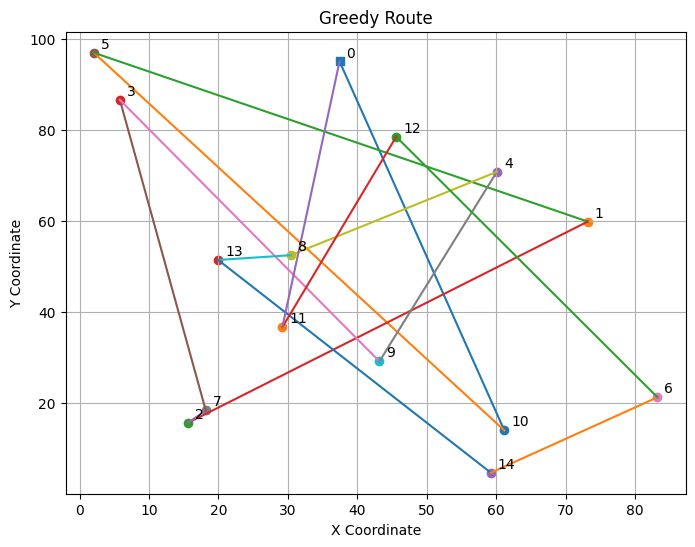

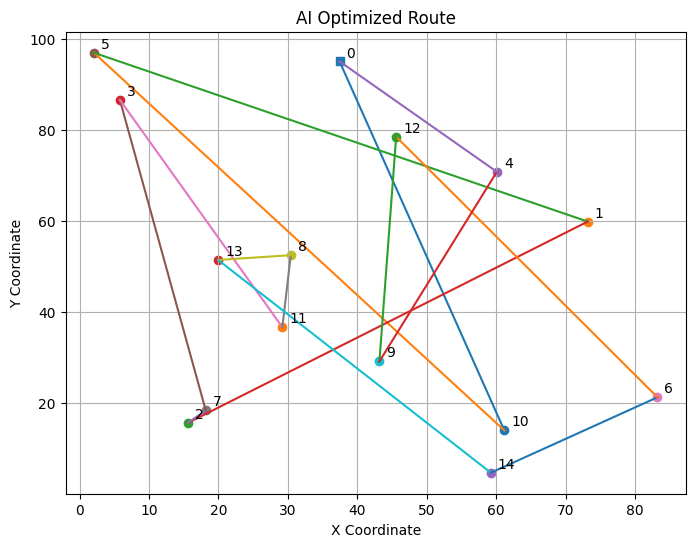

In [ ]:
plot_route(greedy_r, node_coords, "Greedy Route")
plot_route(ai_r, node_coords, "AI Optimized Route")

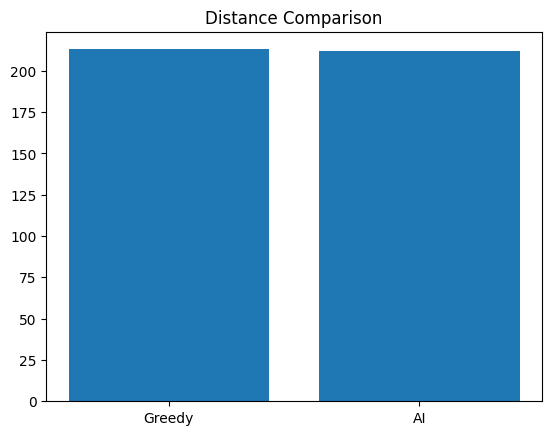

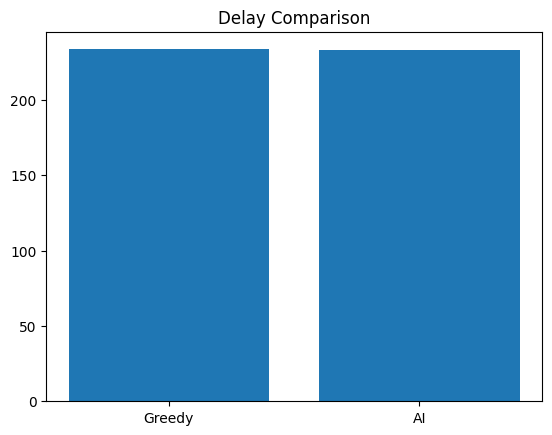

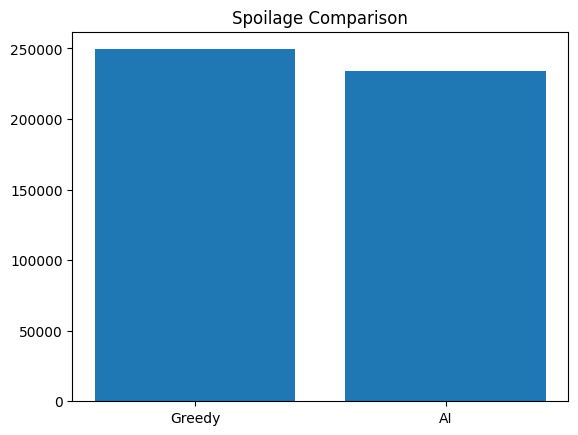

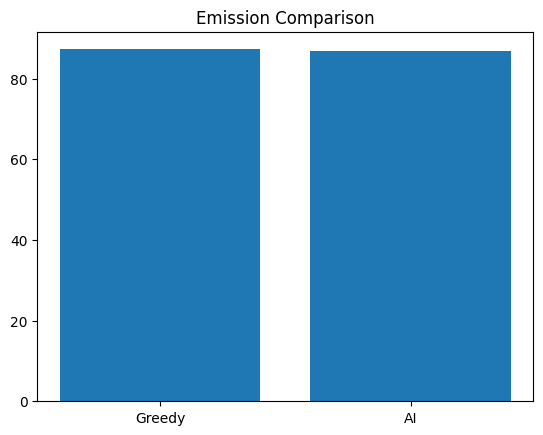

In [ ]:
metrics = ["Distance", "Delay", "Spoilage", "Emission"]

greedy_values = [g_dist, g_delay, g_spoil, g_em]
ai_values = [a_dist, a_delay, a_spoil, a_em]

for i in range(len(metrics)):
    plt.figure()
    plt.bar(["Greedy", "AI"], [greedy_values[i], ai_values[i]])
    plt.title(metrics[i] + " Comparison")
    plt.show()

In [ ]:
# AI WINS WITH LESS SPOILAGE WITH NEGLIGIBLE DIFF IN OTHER FACTORS

In [ ]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt

def animate_route(route, coords, title):

    fig, ax = plt.subplots(figsize=(8,6))

    x_vals = coords[:, 0]
    y_vals = coords[:, 1]

    ax.scatter(x_vals, y_vals)

    for i in range(len(coords)):
        ax.text(coords[i][0] + 1, coords[i][1] + 1, str(i))

    line, = ax.plot([], [], marker='o')

    spoilage_text = ax.text(0.02, 0.95, '', transform=ax.transAxes)
    delay_text = ax.text(0.02, 0.90, '', transform=ax.transAxes)
    emission_text = ax.text(0.02, 0.85, '', transform=ax.transAxes)

    cumulative_time = 0
    total_spoilage = 0
    total_delay = 0
    total_emission = 0

    def update(frame):
        nonlocal cumulative_time, total_spoilage, total_delay, total_emission

        if frame == 0:
            # Reset cumulative metrics for each animation playback if it were to loop
            cumulative_time = 0
            total_spoilage = 0
            total_delay = 0
            total_emission = 0
            x = [coords[route[0]][0]]
            y = [coords[route[0]][1]]
            line.set_data(x, y)
            spoilage_text.set_text("Spoilage: 0")
            delay_text.set_text("Delay: 0")
            emission_text.set_text("Emission: 0")
            return line, spoilage_text, delay_text, emission_text

        prev = route[frame - 1]
        curr = route[frame]

        dist = distance_matrix[prev][curr]
        travel_time = time_matrix[prev][curr]
        delay = predict_delay(dist)

        segment_time = travel_time + delay
        cumulative_time += segment_time

        refrigeration_efficiency = 0.5
        temp_rise = cumulative_time * (1 - refrigeration_efficiency)

        if temp_rise > 4:
            spoil = (temp_rise - 4) * 80
        else:
            spoil = 0

        emission = calculate_emission(dist, delay)

        total_spoilage += spoil
        total_delay += delay
        total_emission += emission

        x = [coords[route[i]][0] for i in range(frame + 1)]
        y = [coords[route[i]][1] for i in range(frame + 1)]

        line.set_data(x, y)

        spoilage_text.set_text(f"Spoilage: {int(total_spoilage)}")
        delay_text.set_text(f"Delay: {int(total_delay)}")
        emission_text.set_text(f"Emission: {int(total_emission)}")

        return line, spoilage_text, delay_text, emission_text

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(route),
        interval=1000,
        repeat=False,
        blit=True
    )

    ax.set_title(title)
    ax.set_xlabel("X Coordinate")
    ax.set_ylabel("Y Coordinate")
    ax.grid(True)

    plt.close(fig) # Prevent static plot from showing

    # Return the animation object
    return ani

In [ ]:
from IPython.display import HTML

num_nodes = len(distance_matrix)
np.random.seed(0) # for reproducibility
node_coords = np.random.rand(num_nodes, 2) * 100 # Scale coordinates for better visual spread

greedy_anim = animate_route(greedy_r, node_coords, "Greedy Route Animation")
display(HTML(greedy_anim.to_jshtml()))

ai_anim = animate_route(ai_r, node_coords, "AI Route Animation")
display(HTML(ai_anim.to_jshtml()))